In [ ]:
# 1. Khai báo các thư viện cần thiết
library(dplyr)    # lọc và xử lý dữ liệu
library(ggplot2)  # vẽ biểu đồ
library(car)      # kiểm định Levene 

In [3]:
# 2.1. Đọc dữ liệu 
df <- read.csv("/kaggle/input/datasets/tunlnguynanh/gpu-ready-for-models/gpu_ready_for_models.csv")

# 2.2. Lọc các nhóm có số lượng mẫu đáng kể (>50) và chuyển sang Factor
df_anova <- df %>%
  group_by(Memory_Type) %>%
  filter(n() > 50) %>%
  ungroup() %>%
  mutate(Memory_Type = as.factor(Memory_Type)) 

# Xem qua dữ liệu sau khi lọc
table(df_anova$Memory_Type)


  DDR2   DDR3   DDR4  GDDR3  GDDR5 GDDR5X 
    80    624     51    297   2020     79 

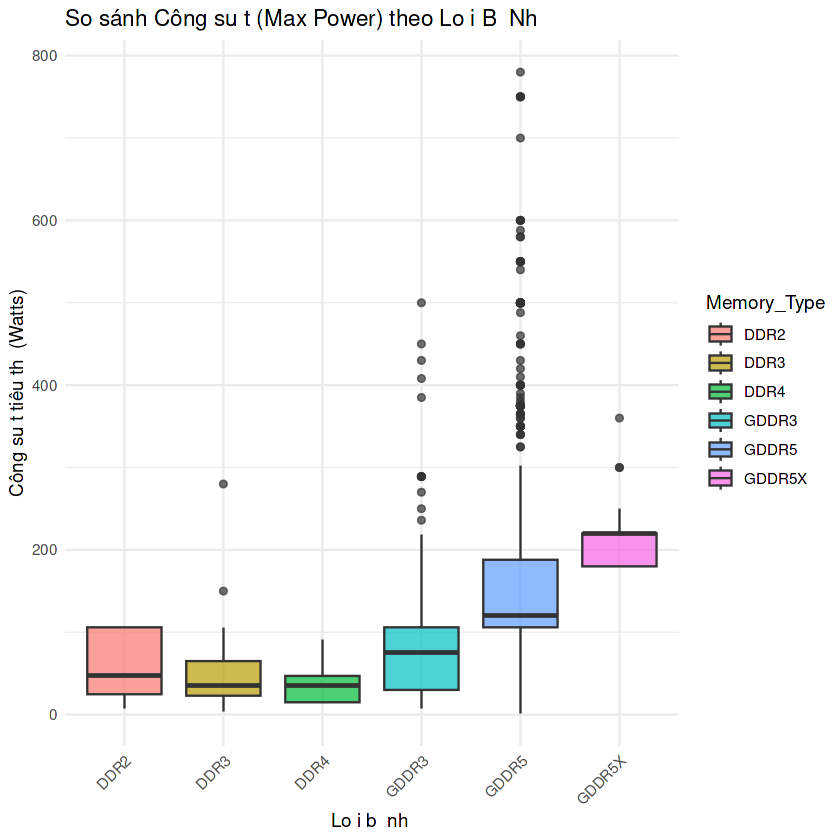

In [4]:
# 3. Vẽ biểu đồ Boxplot so sánh công suất giữa các nhóm
ggplot(df_anova, aes(x = Memory_Type, y = Max_Power, fill = Memory_Type)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal() +
  labs(title = "So sánh Công suất (Max Power) theo Loại Bộ Nhớ",
       x = "Loại bộ nhớ",
       y = "Công suất tiêu thụ (Watts)") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

--- 1. KIỂM ĐỊNH LEVENE (Đồng nhất phương sai) ---
Levene's Test for Homogeneity of Variance (center = median)
        Df F value                Pr(>F)    
group    5  41.823 < 0.00000000000000022 ***
      3145                                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Nhận xét: Nếu Pr(>F) < 0.05, phương sai không đồng nhất.
----------------------------------------------------------

--- 2. ĐỒ THỊ Q-Q PLOT (Kiểm tra phân phối chuẩn) ---
Nhận xét: Các điểm nằm sát đường chéo cho thấy dữ liệu đạt chuẩn.
----------------------------------------------------------

--- 3. BẢNG KẾT QUẢ ANOVA CHÍNH THỨC ---
              Df   Sum Sq Mean Sq F value              Pr(>F)    
Memory_Type    5  7267352 1453470   215.6 <0.0000000000000002 ***
Residuals   3145 21206931    6743                                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
----------------------------------------------------------

--- 4. KIỂM ĐỊNH WELCH'

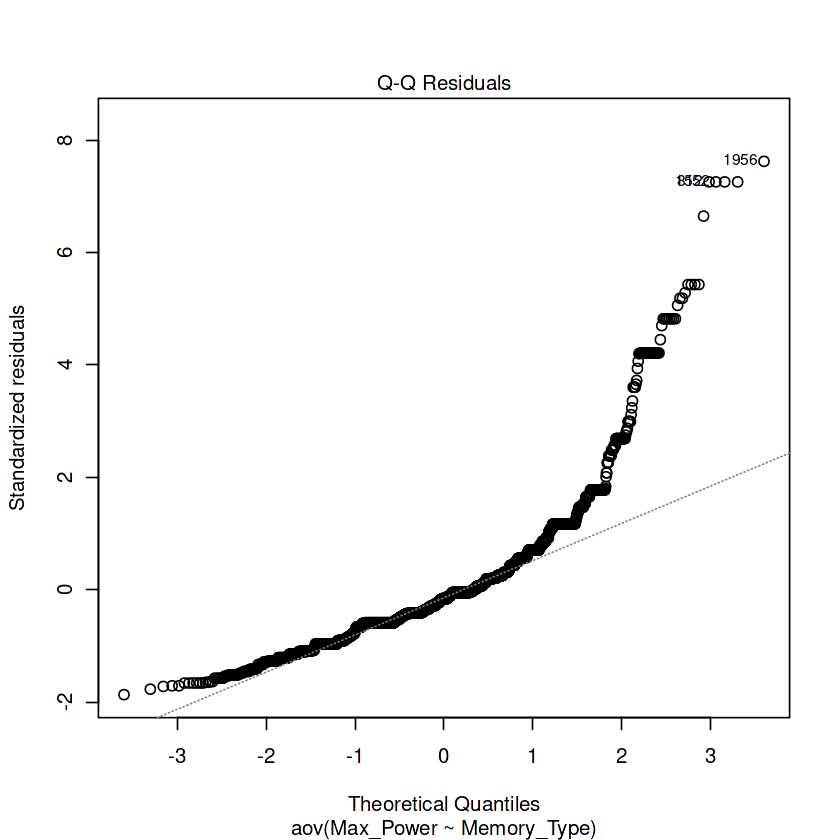

In [8]:
# --- 4. KIỂM ĐỊNH CÁC GIẢ THUYẾT VÀ CHẠY MÔ HÌNH ---

# Cấu hình hệ thống để hiển thị số thưa và rõ ràng
options(scipen = 999)    
options(width = 120)    

# 4.1. Khởi tạo mô hình trước (để các bước sau dùng)
model <- aov(Max_Power ~ Memory_Type, data = df_anova)

# 4.2. Kiểm tra tính đồng nhất phương sai
cat("--- 1. KIỂM ĐỊNH LEVENE (Đồng nhất phương sai) ---\n")
levene_result <- leveneTest(Max_Power ~ Memory_Type, data = df_anova)
print(levene_result)
cat("\nNhận xét: Nếu Pr(>F) < 0.05, phương sai không đồng nhất.\n")
cat("----------------------------------------------------------\n\n")

# 4.3. Kiểm tra tính phân phối chuẩn của phần dư
cat("--- 2. ĐỒ THỊ Q-Q PLOT (Kiểm tra phân phối chuẩn) ---\n")
# Đồ thị Q-Q Plot 
plot(model, which = 2) 
cat("Nhận xét: Các điểm nằm sát đường chéo cho thấy dữ liệu đạt chuẩn.\n")
cat("----------------------------------------------------------\n\n")

# 4.4. Xem bảng kết quả ANOVA chính thức
cat("--- 3. BẢNG KẾT QUẢ ANOVA CHÍNH THỨC ---\n")
print(summary(model))
cat("----------------------------------------------------------\n\n")

# 4.5. Welch's ANOVA
cat("--- 4. KIỂM ĐỊNH WELCH'S ANOVA (Đối chứng) ---\n")
welch_result <- oneway.test(Max_Power ~ Memory_Type, data = df_anova, var.equal = FALSE)
print(welch_result)
cat("\nNhận xét: Kiểm định này dùng khi phương sai không đồng nhất.\n")
cat("----------------------------------------------------------\n\n")

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Max_Power ~ Memory_Type, data = df_anova)

$Memory_Type
                  diff        lwr       upr     p adj
DDR3-DDR2    -11.51026 -39.316732  16.29622 0.8463890
DDR4-DDR2    -21.67475 -63.631567  20.28206 0.6816042
GDDR3-DDR2    25.74196  -3.752765  55.23669 0.1276687
GDDR5-DDR2    94.75458  68.062286 121.44687 0.0000000
GDDR5X-DDR2  155.58908 118.449507 192.72866 0.0000000
DDR4-DDR3    -10.16450 -44.265836  23.93684 0.9579789
GDDR3-DDR3    37.25222  20.745672  53.75876 0.0000000
GDDR5-DDR3   106.26484  95.540765 116.98891 0.0000000
GDDR5X-DDR3  167.09934 139.137306 195.06137 0.0000000
GDDR3-DDR4    47.41672  11.925309  82.90812 0.0019677
GDDR5-DDR4   116.42933  83.230243 149.62842 0.0000000
GDDR5X-DDR4  177.26384 135.203771 219.32390 0.0000000
GDDR5-GDDR3   69.01262  54.461176  83.56406 0.0000000
GDDR5X-GDDR3 129.84712 100.205697 159.48855 0.0000000
GDDR5X-GDDR5  60.83450  33.980199  87.6

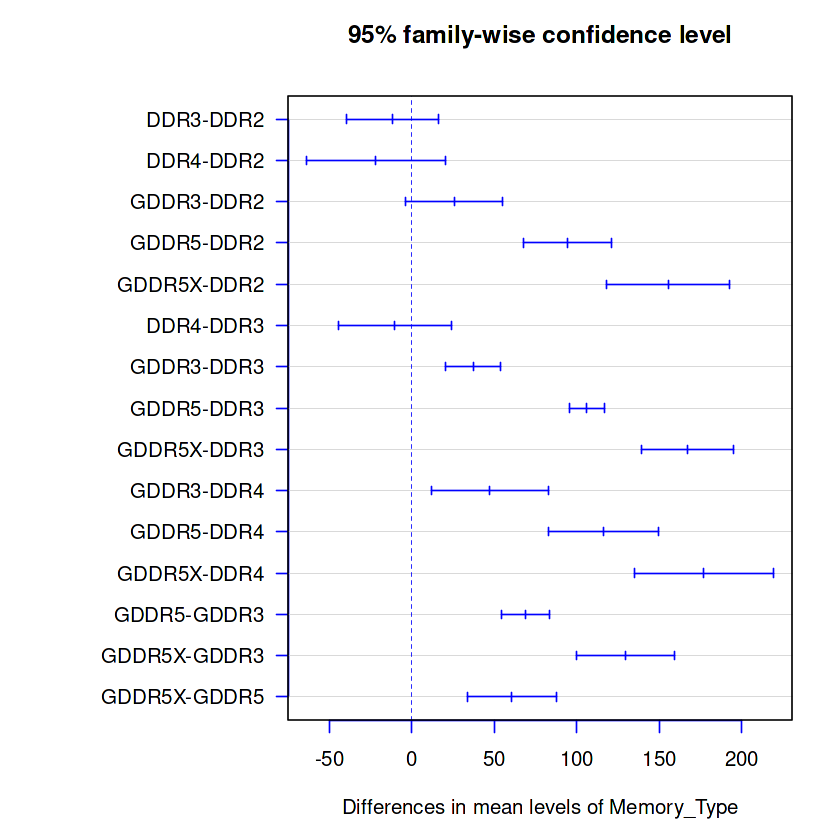

In [9]:
# 5.1. So sánh cặp bằng Tukey HSD
tukey_results <- TukeyHSD(model)
print(tukey_results)

# 5.2. Vẽ biểu đồ so sánh các cặp để dễ quan sát
# (Điều chỉnh lề để không bị mất tên các cặp)
par(mar=c(5, 12, 4, 2)) 
plot(tukey_results, las = 1, col = "blue")

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Max_Power ~ Memory_Type, data = df_anova)

$Memory_Type
                  diff        lwr       upr     p adj
DDR3-DDR2    -11.51026 -39.316732  16.29622 0.8463890
DDR4-DDR2    -21.67475 -63.631567  20.28206 0.6816042
GDDR3-DDR2    25.74196  -3.752765  55.23669 0.1276687
GDDR5-DDR2    94.75458  68.062286 121.44687 0.0000000
GDDR5X-DDR2  155.58908 118.449507 192.72866 0.0000000
DDR4-DDR3    -10.16450 -44.265836  23.93684 0.9579789
GDDR3-DDR3    37.25222  20.745672  53.75876 0.0000000
GDDR5-DDR3   106.26484  95.540765 116.98891 0.0000000
GDDR5X-DDR3  167.09934 139.137306 195.06137 0.0000000
GDDR3-DDR4    47.41672  11.925309  82.90812 0.0019677
GDDR5-DDR4   116.42933  83.230243 149.62842 0.0000000
GDDR5X-DDR4  177.26384 135.203771 219.32390 0.0000000
GDDR5-GDDR3   69.01262  54.461176  83.56406 0.0000000
GDDR5X-GDDR3 129.84712 100.205697 159.48855 0.0000000
GDDR5X-GDDR5  60.83450  33.980199  87.6

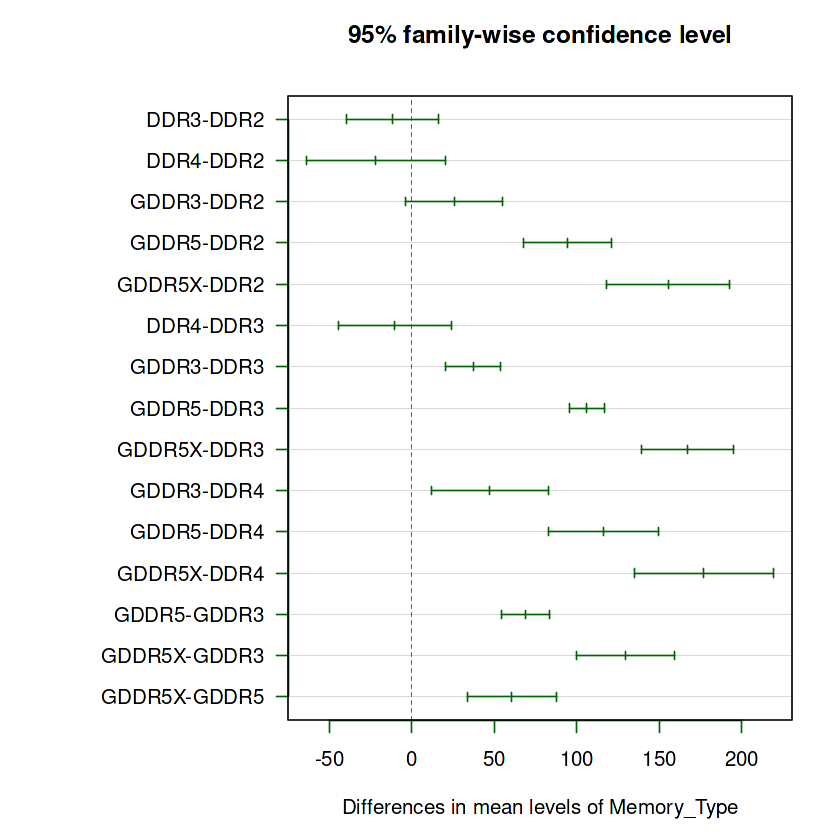

In [12]:
# 6. So sánh cặp bằng Tukey HSD
TukeyHSD(model)
# Vẽ biểu đồ so sánh các cặp 
par(mar=c(5, 12, 4, 2)) 
plot(TukeyHSD(model), las = 1, col = "darkgreen")